In [2]:
from prody import *;from numpy import *
from matplotlib.pyplot import *
%matplotlib inline
confProDy(auto_show=False)
confProDy(auto_secondary=True)

@> ProDy is configured: auto_show=False
@> ProDy is configured: auto_secondary=True


In [3]:
p38 = parsePDB('1p38');p38

@> Connecting wwPDB FTP server RCSB PDB (USA).
@> pdb1p38.ent.gz download failed. 1p38 does not exist on ftp.wwpdb.org.
@> PDB download via FTP completed (0 downloaded, 1 failed).
@> Downloading PDB files via FTP failed, trying HTTP.
@> 1p38 downloaded (1p38.pdb.gz)
@> PDB download via HTTP completed (1 downloaded, 0 failed).
@> 2962 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> Secondary structures were assigned to 188 residues.


<AtomGroup: 1p38 (2962 atoms)>

In [5]:
p38["A"];p38['A'].getSequence()

'ERPTFYRQELNKTIWEVPERYQNLSPVGSGAYGSVCAAFDTKTGHRVAVKKLSRPFQSIIHAKRTYRELRLLKHMKHENVIGLLDVFTPARSLEEFNDVYLVTHLMGADLNNIVKCQKLTDDHVQFLIYQILRGLKYIHSADIIHRDLKPSNLAVNEDCELKILDFGLARHTDDEMTGYVATRWYRAPEIMLNWMHYNQTVDIWSVGCIMAELLTGRTLFPGTDHIDQLKLILRLVGTPGAELLKKISSESARNYIQSLAQMPKMNFANVFIGANPLAVDLLEKMLVLDSDKRITAAQALAHAYFAQYHDPDDEPVADPYDQSFESRDLLIDEWKSLTYDEVISFVPPPLD'

In [7]:
p38[10].getResnum();p38['A', 5]

<Residue: ARG 5 from Chain A from 1p38 (11 atoms)>

In [8]:
p38['A', 5].getNames()

array(['N', 'CA', 'C', 'O', 'CB', 'CG', 'CD', 'NE', 'CZ', 'NH1', 'NH2'],
      dtype='<U6')

In [9]:
ca = p38.select('calpha');ca

<Selection: 'calpha' from 1p38 (351 atoms)>

In [10]:
bb = p38.select('backbone');bb

<Selection: 'backbone' from 1p38 (1404 atoms)>

In [11]:
chainA_ca = parsePDB('1p38', chain='A', subset='ca')

@> PDB file is found in working directory (1p38.pdb.gz).
@> 351 atoms and 1 coordinate set(s) were parsed in 0.01s.
@> Secondary structures were assigned to 188 residues.


In [12]:
chA = p38.select('calpha and chain A');chA

<Selection: 'calpha and chain A' from 1p38 (351 atoms)>

In [13]:
bound = parsePDB('1zz2')

@> Connecting wwPDB FTP server RCSB PDB (USA).
@> 1zz2 downloaded (1zz2.pdb.gz)
@> PDB download via FTP completed (1 downloaded, 0 failed).
@> 2872 atoms and 1 coordinate set(s) were parsed in 0.05s.
@> Secondary structures were assigned to 220 residues.


In [14]:
results = matchChains(p38, bound);results[0]

@> Checking AtomGroup 1p38: 1 chains are identified
@> Checking AtomGroup 1zz2: 1 chains are identified
@> Trying to match chains based on residue numbers and names:
@>   Comparing Chain A from 1p38 (len=351) and Chain A from 1zz2 (len=337):
@> 	Match: 337 residues match with 99% sequence identity and 96% overlap.


(<AtomMap: Chain A from 1p38 -> Chain A from 1zz2 from 1p38 (337 atoms)>,
 <AtomMap: Chain A from 1zz2 -> Chain A from 1p38 from 1zz2 (337 atoms)>,
 99.40652818991099,
 96.01139601139602)

In [16]:
apo_chA, bnd_chA, seqid, overlap = results[0];apo_chA

<AtomMap: Chain A from 1p38 -> Chain A from 1zz2 from 1p38 (337 atoms)>

In [17]:
bnd_chA

<AtomMap: Chain A from 1zz2 -> Chain A from 1p38 from 1zz2 (337 atoms)>

In [18]:
seqid

99.40652818991099

In [19]:
calcRMSD(bnd_chA, apo_chA)

72.93023086946586

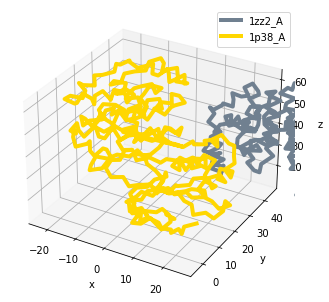

In [20]:
showProtein(bnd_chA);showProtein(apo_chA);legend();

In [21]:
import py3Dmol;showProtein(p38)

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [22]:
import py3Dmol;showProtein(apo_chA)

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [23]:
import py3Dmol;showProtein(bnd_chA)

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [24]:
writePDB('bound_aligned.pdb', bnd_chA)

'bound_aligned.pdb'

In [26]:
import nglview;view=nglview.show_file("bound_aligned.pdb");view

NGLWidget()

In [63]:
import nglview;view=nglview.show_pdbid("1p38");view

NGLWidget()

In [64]:
#view.add_licorice("5");view.remove_label()
#view.add_label("5",radius=1,color="blue",
 #             label_type="atomname")
view.add_ball_and_stick(color="white")
#view.add_ball_and_stick("bnd_chA",color="green")
#view.add_ball_and_stick("apo_chA",color="spectrum")

In [42]:
import pymol;from pymol import cmd
pymol.pymol_argv = ['pymol', '-qc']
#cmd.fetch('.pdb')
!pwd

/home/pi/Documents/sage


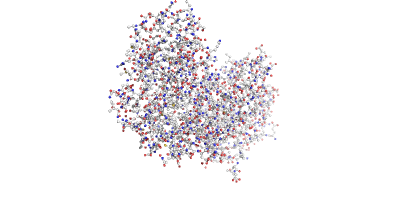

In [69]:
from IPython.display import Image
cmd.do('reinitialize;fetch 1p38;show cartoon;\
preset.ball_and_stick(selection="all", mode=1);\
color white, elem C;viewport 400,200;')
#show sticks, resn GTP;show spheres, name MG;\
#set label_size,12;rotate x,180;\
#cmd.do('label (gly),name')
cmd.png('1p.png', ray=1);Image(filename='1p.png')

In [85]:
from Bio.PDB.PDBParser import PDBParser
p = PDBParser(PERMISSIVE=1)
structure_id = "1p38"
#structure = p.get_structure(structure_id, fn)

In [82]:
from Bio.PDB.MMCIFParser import MMCIFParser
parser = MMCIFParser()
structure = parser.get_structure('1p38', '1p38.cif')
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
mmcif_dict = MMCIF2Dict('1p38.cif')

In [87]:
sc = mmcif_dict['_exptl_crystal.density_percent_sol'];sc

['58.0']

In [90]:
#y_list = mmcif_dict['_atom_site.Cartn_y'];y_list

In [94]:
from Bio.PDB import PDBIO;io = PDBIO()
io.set_structure(structure);io.save('struc.pdb')

In [105]:
from Bio.PDB.PDBIO import Select
class GlySelect(Select):
    def accept_residue(self, residue):
        if residue.get_name() == 'Gly':
            return True
        else:
            return False